When all experiments have run this script can be used to do the main analysis. For now the script expects the experiment configurations to be in the graveyard folder and the experiment results to be in the logs folder.

In [1]:
from pathlib import Path

import pandas as pd

from superresassess.experiments import ExperimentConfiguration
from superresassess.configurations_io import read_yaml_as_configuration
from superresassess.assessment.results import InternalTestResult, ExternalTestResult

In [2]:
ran_experiments_folder = Path("../graveyard/") 
ran_experiments_paths = ran_experiments_folder.glob("*.yaml")

In [3]:
ran_experiments = [read_yaml_as_configuration(yaml_path=yaml_path, configuration=ExperimentConfiguration).dict() for yaml_path in ran_experiments_paths]

Let's build a pandas dataframe using the experiment configurations

In [4]:
df = pd.DataFrame.from_records(ran_experiments)

In [5]:
df.head()

,assessment_method,train_val_test_ratio,log_path,learning_rate,max_epochs,training_dataloader_config,validation_dataloader_config,testing_dataloader_config,n_internal_images,experiment_id,seed
0,three_way_holdout,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2043, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2043, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2043, 'dict_keys': ('img', 'lab'), 'b...",20,00058,2043
1,k_fold_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2038, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2038, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2038, 'dict_keys': ('img', 'lab'), 'b...",20,00044,2038
2,nested_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2048, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2048, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2048, 'dict_keys': ('img', 'lab'), 'b...",20,00075,2048
3,nested_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2033, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2033, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2033, 'dict_keys': ('img', 'lab'), 'b...",20,00030,2033
4,k_fold_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2028, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2028, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2028, 'dict_keys': ('img', 'lab'), 'b...",20,00014,2028


In [6]:
from functools import partial

def add_internal_assessment(serie: pd.Series, log_path: Path) -> float:
    experiment_id = serie["experiment_id"]
    internal_assessment_path = log_path / str(experiment_id) / "internal_test_result.yaml"
    internal_assessment = read_yaml_as_configuration(yaml_path=internal_assessment_path, configuration=InternalTestResult)
    return internal_assessment.internal_testing_loss
    
add_internal = partial(add_internal_assessment, log_path = Path("../logs/"))

def add_external_assessment(serie: pd.Series, log_path: Path) -> float:
    experiment_id = serie["experiment_id"]
    external_assessment_path = log_path / str(experiment_id) / "external_test_result.yaml"
    external_assessment = read_yaml_as_configuration(yaml_path=external_assessment_path, configuration=ExternalTestResult)
    return external_assessment.external_testing_loss
    
add_external = partial(add_external_assessment, log_path = Path("../logs/"))

In [7]:
df["internal_test_result"] = df.apply(add_internal, axis=1)

In [8]:
df["external_test_result"] = df.apply(add_external, axis=1)

In [9]:
df.sort_values(by="experiment_id")

,assessment_method,train_val_test_ratio,log_path,learning_rate,max_epochs,training_dataloader_config,validation_dataloader_config,testing_dataloader_config,n_internal_images,experiment_id,seed,internal_test_result,external_test_result
29,three_way_holdout,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2024, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2024, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2024, 'dict_keys': ('img', 'lab'), 'b...",20,00001,2024,13.320100,12.741659
7,k_fold_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2024, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2024, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2024, 'dict_keys': ('img', 'lab'), 'b...",20,00002,2024,13.112461,12.290891
10,nested_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2024, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2024, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2024, 'dict_keys': ('img', 'lab'), 'b...",20,00003,2024,13.628972,12.439690
47,three_way_holdout,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2025, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2025, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2025, 'dict_keys': ('img', 'lab'), 'b...",20,00004,2025,13.277380,13.603678
26,k_fold_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2025, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2025, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2025, 'dict_keys': ('img', 'lab'), 'b...",20,00005,2025,12.206222,12.809666
...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,k_fold_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2052, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2052, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2052, 'dict_keys': ('img', 'lab'), 'b...",20,00086,2052,12.291074,12.611477
6,nested_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2052, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2052, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2052, 'dict_keys': ('img', 'lab'), 'b...",20,00087,2052,12.926549,12.839166
22,three_way_holdout,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2053, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2053, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2053, 'dict_keys': ('img', 'lab'), 'b...",20,00088,2053,11.901964,13.397179
65,k_fold_cross_validation,"(0.6, 0.2, 0.2)",logs,0.001,200,"{'seed': 2053, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2053, 'dict_keys': ('img', 'lab'), 'b...","{'seed': 2053, 'dict_keys': ('img', 'lab'), 'b...",20,00089,2053,11.882142,13.527961


In [10]:
df["internal_error"] = df["external_test_result"] - df["internal_test_result"]
df["absolute_internal_error"] = (df["internal_error"]**2)**(1/2)

In [11]:
import seaborn as sns

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


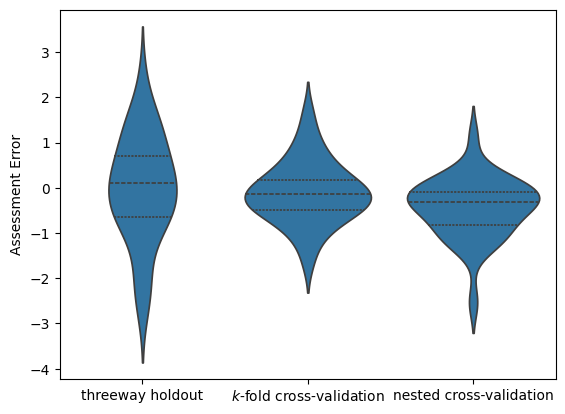

In [27]:
tick_label_mapper = {
    "three_way_holdout": "threeway holdout",
    "k_fold_cross_validation": "$k$-fold cross-validation",
    "nested_cross_validation": "nested cross-validation"
}
violin_ax = sns.violinplot(data=df, y="internal_error", x="assessment_method", inner="quart")
new_tick_labels = [tick_label_mapper[old_text.get_text()] for old_text in violin_ax.get_xticklabels()]
violin_ax.set_xlabel("")
violin_ax.set_ylabel("Assessment Error")
violin_ax.set_xticklabels(new_tick_labels)
violin_ax.get_figure().savefig("../figures/assessement_error.png")

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


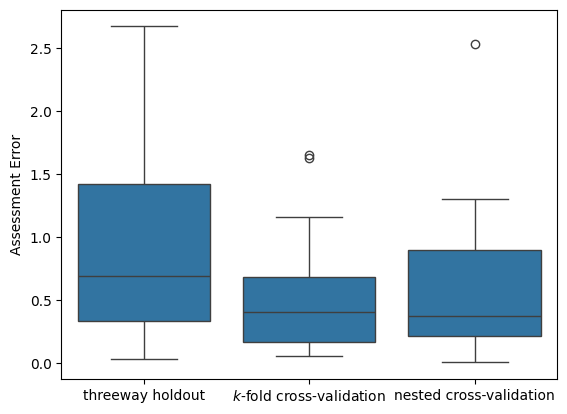

In [29]:
tick_label_mapper = {
    "three_way_holdout": "threeway holdout",
    "k_fold_cross_validation": "$k$-fold cross-validation",
    "nested_cross_validation": "nested cross-validation"
}
box_ax = sns.boxplot(data=df, y="absolute_internal_error", x="assessment_method")
new_tick_labels = [tick_label_mapper[old_text.get_text()] for old_text in box_ax.get_xticklabels()]
box_ax.set_xlabel("")
box_ax.set_ylabel("Assessment Error")
box_ax.set_xticklabels(new_tick_labels)
box_ax.get_figure().savefig("../figures/absolute_assessement_error.png")

# Statistical Analysis
## Reorder data
In the current dataframe, every method in every iteration has its own row. We would like for every row to contain the result of every method, so that we can compare the method iteration by iteration. To do so, we first find the seed (which is equivalent to the iteration), and then group all results.

In [34]:
# Get all unique seeds
df["seed"].unique()

array([2043, 2038, 2048, 2033, 2028, 2052, 2024, 2035, 2041, 2045, 2031,
       2040, 2027, 2029, 2050, 2039, 2025, 2051, 2053, 2026, 2030, 2047,
       2049, 2044, 2046, 2034, 2036, 2032, 2042, 2037])

In [35]:
# Initialize an empty list of iterations. Every iterations is a dictionary containing a seed, a threeway holdout error,
# a k-fold cross validation error and a nested cross-validation error. The length of this list is as long as the number
# of unique seeds.
list_of_iterations = []

for seed in df["seed"].unique():
    current_seed_df = df[df["seed"] == seed]
    list_of_iterations.append({
        "seed": seed,
        "threeway_error": current_seed_df[current_seed_df["assessment_method"] == "three_way_holdout"]["internal_error"].to_numpy(),
        "kfold_error": current_seed_df[current_seed_df["assessment_method"] == "k_fold_cross_validation"]["internal_error"].to_numpy(),
        "nested_error": current_seed_df[current_seed_df["assessment_method"] == "nested_cross_validation"]["internal_error"].to_numpy(),
    })

In [36]:
# Show the first iteration
print(list_of_iterations[0])

{'seed': 2043, 'threeway_error': array([-1.57516766]), 'kfold_error': array([0.16530609]), 'nested_error': array([-0.10475578])}


In [38]:
# Move the list of iterations back to a dataframe
transposed_df = pd.DataFrame.from_records(list_of_iterations)

In [39]:
# and finally type hint all data
type_dict = {
    "seed": int,
    "threeway_error": float,
    "kfold_error": float,
    "nested_error": float,
}
transposed_df = transposed_df.astype(type_dict)
transposed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   seed            30 non-null     int64  
 1   threeway_error  30 non-null     float64
 2   kfold_error     30 non-null     float64
 3   nested_error    30 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.1 KB


In [40]:
transposed_df.describe()

,seed,threeway_error,kfold_error,nested_error
count,30.000000,30.000000,30.000000,30.000000
mean,2038.500000,-0.019454,-0.101426,-0.434162
std,8.803408,1.177410,0.686733,0.670406
min,2024.000000,-2.669316,-1.621702,-2.529483
25%,2031.250000,-0.652483,-0.482065,-0.813483
50%,2038.500000,0.113884,-0.130970,-0.318476
75%,2045.750000,0.693075,0.171821,-0.091726
max,2053.000000,2.372856,1.645819,1.128435


## Permutation tests

### Threeway v. Kfold

In [46]:
import numpy as np
import numpy.typing as npt

# Accumulate data
threeway_v_kfold = np.asarray(transposed_df['threeway_error'].to_list() + transposed_df['kfold_error'].to_list())

In [47]:
print(np.version.version)

1.26.4


In [48]:
from typing import Callable, Any

NDArrayFloat = npt.NDArray[np.float_]

def standard_deviation_difference(
    group1: NDArrayFloat,
    group2: NDArrayFloat,
) -> float:
    return group1.std() - group2.std()

def interquartile_range_difference(
    group1: NDArrayFloat,
    group2: NDArrayFloat,
) -> np.floating[Any]:
    iqr1 = np.percentile(group1, 75) - np.percentile(group1, 25)
    iqr2 = np.percentile(group2, 75) - np.percentile(group2, 25)
    return iqr1 - iqr2


def mean_difference(
    group1: NDArrayFloat,
    group2: NDArrayFloat,
) -> float:
    return group1.mean() - group2.mean()

def median_difference(
    group1: NDArrayFloat,
    group2: NDArrayFloat,
) -> np.floating[Any]:
    return np.median(group1) - np.median(group2)

def permutation_test(
    data: npt.ArrayLike,
    group_one_size: int, # For now hardcode two groups, should be bit more generalized
    difference_function: Callable,
    number_of_permutations: int = 1_000_000,
) -> npt.ArrayLike:

    # List to accumulate data from difference function
    differences = []

    # make hard copy as not to mess with the original data
    function_data = np.copy(data)

    # the loop can probably done in vectorized fashion using numpy
    while number_of_permutations > 0:
        number_of_permutations -= 1

        # Randomize order of data
        np.random.shuffle(function_data)

        # Split data in group size
        group1 = function_data[0:group_one_size]
        group2 = function_data[group_one_size:]

        differences.append(difference_function(group1, group2))

    return np.asarray(differences)


In [ ]:
permutation_mean_results = permutation_test(threeway_v_kfold, 30, mean_difference)

In [50]:
permutation_std_results_df = pd.DataFrame(permutation_std_results, columns=["std_difference"])

In [51]:
permutation_std_results_df.describe()

,std_difference
count,1000000.000000
mean,0.000125
std,0.202476
min,-0.846583
25%,-0.139338
50%,-0.000117
75%,0.139881
max,0.795209


In [52]:
sns.displot(permutation_results_df, x="std_difference")

NameError: name 'permutation_results_df' is not defined

In [134]:
over = permutation_results > 0.490677
under = permutation_results < -0.490677

In [135]:
over.sum() / 1_000_000

0.006202

In [136]:
under.sum() / 1_000_000

0.006213

In [137]:
permutation_mean_results = permutation_test(threeway_v_kfold, 30, mean_difference)

In [140]:
permutation_mean_results_df = pd.DataFrame(permutation_mean_results, columns=["mean_difference"])

In [141]:
permutation_mean_results_df.describe()

,mean_difference
count,1000000.000000
mean,-0.000278
std,0.247292
min,-1.045320
25%,-0.169181
50%,-0.000592
75%,0.168606
max,1.144818


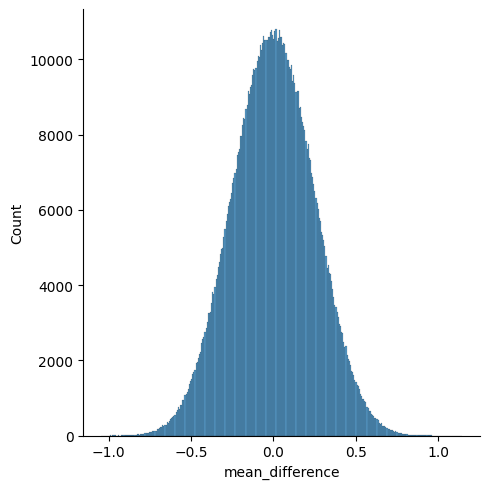

In [142]:
sns.displot(permutation_mean_results_df, x="mean_difference")

In [143]:
mean_over = permutation_mean_results > 0.081886

In [145]:
mean_over.sum() / 1_000_000

0.371136